## Radar plots and Tables

& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM \\
STATIC & 0.773$\pm$0.034 & 0.268$\pm$0.014 & 0.157$\pm$0.009 & 0.915$\pm$0.053 & 0.265$\pm$0.026 & 0.597$\pm$0.026 & 0.156 & 
\cm{777.0}{589.0}{10.2}{109.8}{1366.0}{120.0} \\
STATIC+EVENT-CNT & 0.888$\pm$0.030 & 0.430$\pm$0.038 & 0.294$\pm$0.036 & 0.817$\pm$0.084 & 0.419$\pm$0.042 & 0.823$\pm$0.031 & 0.079 & 
\cm{1125.0}{241.0}{22.0}{98.0}{1366.0}{120.0} \\
STATIC+BiPadLSTM & 0.867$\pm$0.045 & 0.510$\pm$0.054 & 0.414$\pm$0.052 & 0.672$\pm$0.091 & 0.474$\pm$0.062 & 0.896$\pm$0.015 & 0.061 & 
\cm{1250.2}{115.8}{39.4}{80.6}{1366.0}{120.0} \\
STATIC+Med2Vec & 0.898$\pm$0.029 & 0.504$\pm$0.042 & 0.385$\pm$0.044 & 0.742$\pm$0.085 & 0.478$\pm$0.050 & 0.882$\pm$0.016 & 0.064 & 
\cm{1221.4}{144.6}{31.0}{89.0}{1366.0}{120.0} \\
STATIC+Dipole & 0.881$\pm$0.033 & 0.520$\pm$0.050 & 0.426$\pm$0.043 & 0.675$\pm$0.098 & 0.484$\pm$0.059 & 0.900$\pm$0.012 & 0.060 & 
\cm{1256.0}{110.0}{39.0}{81.0}{1366.0}{120.0} \\
STATIC+CEHR-BERT & 0.864$\pm$0.048 

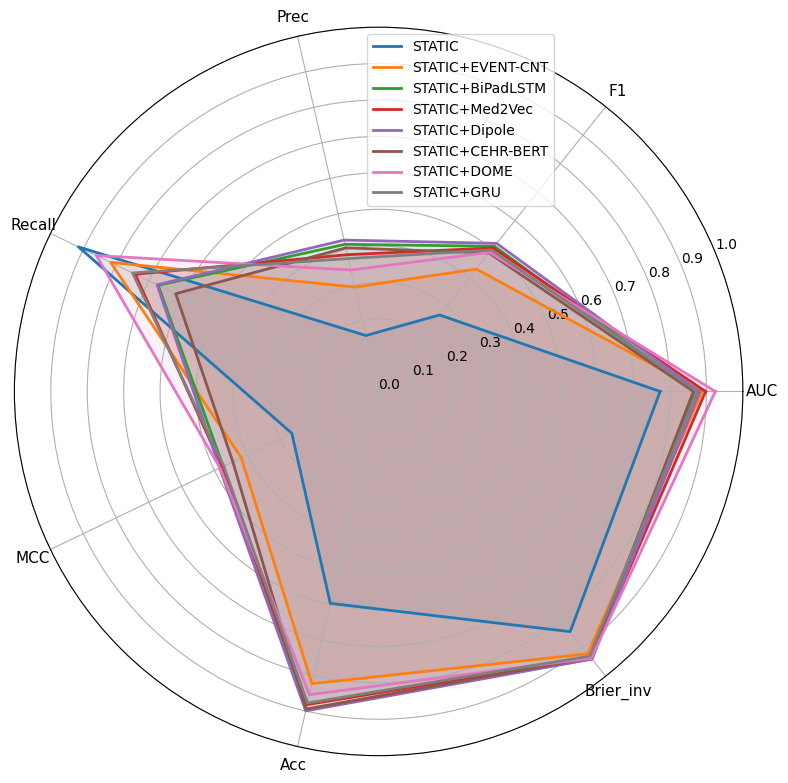

& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM \\
STATIC & 0.540$\pm$0.066 & 0.132$\pm$0.062 & 0.074$\pm$0.035 & 0.646$\pm$0.330 & 0.036$\pm$0.062 & 0.428$\pm$0.255 & 0.150 & 
\cm{328.2}{473.8}{24.8}{45.2}{802.0}{70.0} \\
STATIC+EVENT-CNT & 0.775$\pm$0.053 & 0.316$\pm$0.074 & 0.219$\pm$0.067 & 0.600$\pm$0.125 & 0.266$\pm$0.090 & 0.786$\pm$0.047 & 0.095 & 
\cm{643.4}{158.6}{28.0}{42.0}{802.0}{70.0} \\
STATIC+BiPadLSTM & 0.749$\pm$0.094 & 0.402$\pm$0.099 & 0.396$\pm$0.096 & 0.426$\pm$0.136 & 0.353$\pm$0.107 & 0.900$\pm$0.022 & 0.073 & 
\cm{754.6}{47.4}{40.2}{29.8}{802.0}{70.0} \\
STATIC+Med2Vec & 0.699$\pm$0.102 & 0.307$\pm$0.133 & 0.403$\pm$0.130 & 0.260$\pm$0.137 & 0.274$\pm$0.132 & 0.911$\pm$0.015 & 0.071 & 
\cm{775.8}{26.2}{51.8}{18.2}{802.0}{70.0} \\
STATIC+Dipole & 0.684$\pm$0.108 & 0.388$\pm$0.125 & 0.513$\pm$0.207 & 0.340$\pm$0.132 & 0.363$\pm$0.131 & 0.916$\pm$0.020 & 0.068 & 
\cm{774.8}{27.2}{46.2}{23.8}{802.0}{70.0} \\
STATIC+CEHR-BERT & 0.766$\pm$0.103 & 0.372$\pm$0.146 

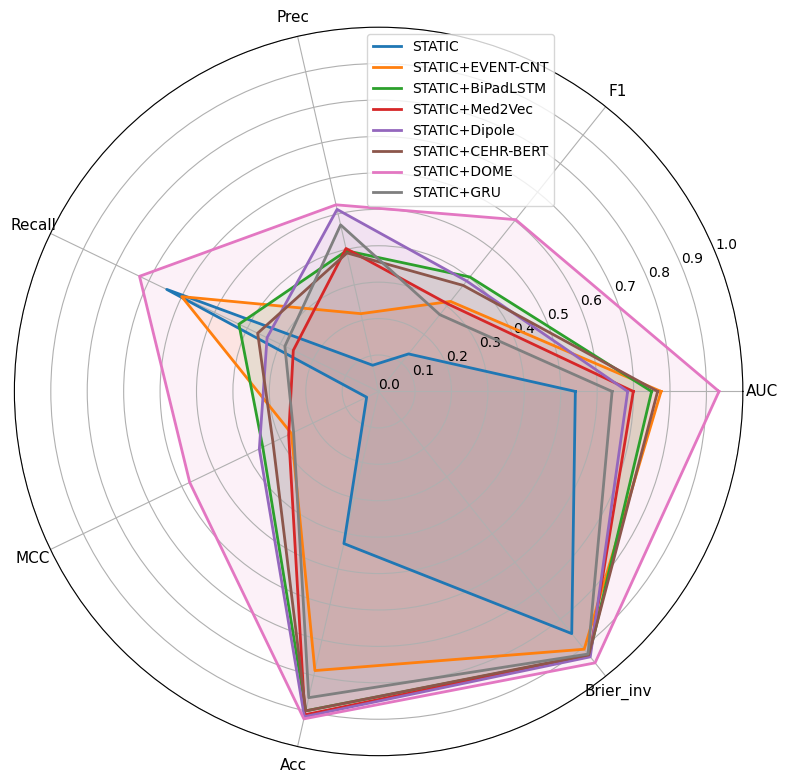

In [10]:
import pandas as pd
import numpy as np
from scripts.plotting import plot_radar

iter = 5
exclude_methods = [] #['STATIC+GRU-D']
metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
results_dir = "results_final"
fig_dir = "figures_final"
dfs = {}


for g in ['INA_icd', 'MIMIC']:
    for p in tmetrics:
        print(f"& {p} ", end='')
        dfs[p] = pd.read_csv(f"{results_dir}/resdata_{p}_{g}_ITER{iter}.csv", index_col=0)
        dfs[p].drop(columns=exclude_methods, inplace=True)
    print("\\\\")
    dfm = pd.DataFrame(columns = tmetrics, index = dfs[p].columns)
    dfm.index.name = "Model"
    for method in dfs[p].columns:
        print(f"{method} & ", end='')
        values = []
        for p in tmetrics:
            if p == "CM":
                cm = dfs[p][method].apply(lambda x: np.array(eval(x))).sum() / 5
                values += [cm]
                print(f"\\cm{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}} \\\\")
            elif p == 'Brier':
                print(f"{dfs[p][method].mean():.3f} & ", end="\n")
                values += [1 - dfs[p][method].mean()]
            else:
                print(f"{dfs[p][method].mean():.3f}$\pm${dfs[p][method].std():.3f} & ", end="")
                values += [dfs[p][method].mean()]
        dfm.loc[method] = values
    print()
    dfm.rename(columns={"Brier": "Brier_inv"}, index=index_replacements, inplace=True)
    fig = plot_radar(dfm,metrics + ['Brier_inv'])
    fig.savefig(f"{fig_dir}/{g}_radar.png")

## Calibration Curves

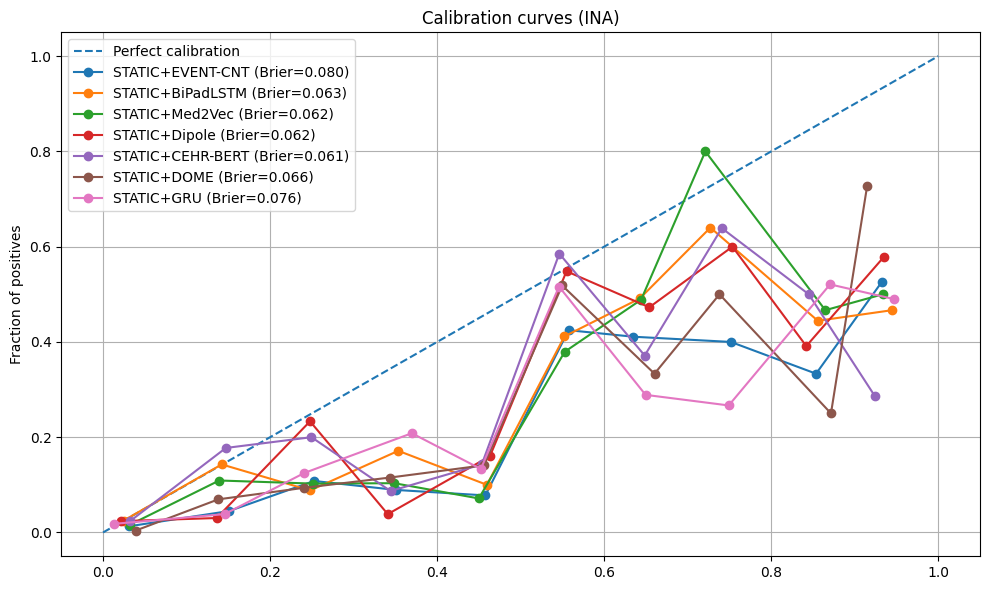

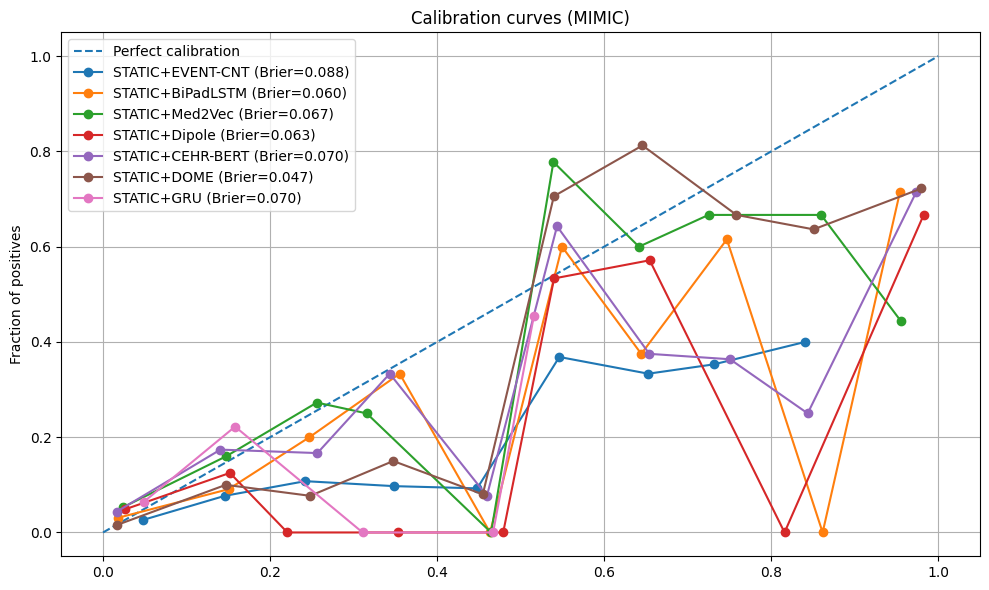

In [17]:
from scripts.plotting import plot_calibration
import pickle
iter = 1
methods = [#['STATIC'],
           ['STATIC', 'EVENT-CNT'],
           ['STATIC', 'BiPadLSTM'], 
                    ['STATIC', 'Med2Vec'],
                    ['STATIC', 'Dipole'],
                    ['STATIC', 'CEHR-BERT'],
                    ['STATIC', 'DOME'],
                    ['STATIC', 'GRU'],
                    ]
d = {'INA_icd': 'INA', 'MIMIC': 'MIMIC'}
for g in ['INA_icd', 'MIMIC']:
    prob_pred = {"+".join(m): [] for m in methods}
    prob_true = {"+".join(m): [] for m in methods}
    all_runs = {"+".join(m): ([], []) for m in methods}
    for m in methods:
        with open(f"{results_dir}/results_{g}_{'_'.join(m)}_ITER{iter}.pkl", "rb") as f:
            results = pickle.load(f)
        prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
        prob_true["+".join(m)] += list(results['calibration_prob_true'])
        all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                    all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
    # label corrections
    fig = plot_calibration(prob_pred, prob_true,all_runs,title=f"Calibration curves ({d[g]})")
    fig.savefig(f"{fig_dir}/caliba_curve_{g}_ITER{iter}.png")